<a href="https://colab.research.google.com/github/Yukti123Ramtani/data-science-projects/blob/main/mltalgos_appendix-tools-for-deep-learning/clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-means Clustering - Lloyd's Algorithm
* It is an unsupervised learning algorithm.
* The algorithm tries to capture 'similarity' between datapoints, and assign a cluster indicator for each clique.

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns ; sns.set()

from sklearn.datasets import make_blobs
from scipy.spatial.distance import cdist


**K-means clustering algorithm**

It is an iterative algorithm that proceeds as follows :

**Input :**

*   ***n*** training examples represented with ** m **
 features.
*   Number of centroids:



In [ ]:
cluster_count=3

In [75]:
X,y=make_blobs(n_samples=300, n_features=2 ,centers=3,random_state=1) #n_samples=number of data points,n_features=d=2,centers=number of clusters,
#random_state=1 means the random number generator will always start from the same seed value (here, 1).
X.shape,y.shape

((300, 2), (300,))

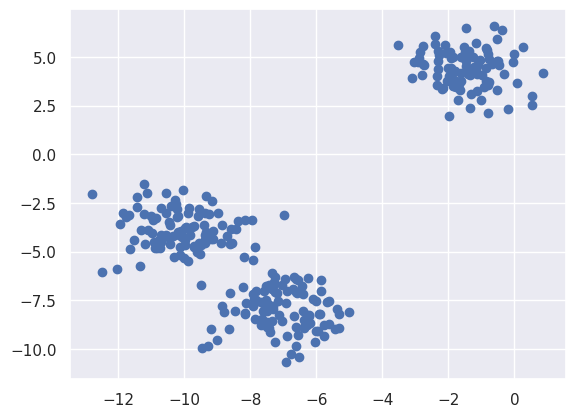

In [73]:
plt.scatter(X[:,0],X[:,1])
plt.show()

In [82]:
np.random.seed(1234)
#np.random.seed(1234) ensures that your random choices (like picking centroids)
#are the same every time you run the code, which is important for reproducibility in experiments and debugging.so as to print same randome values everytume
centroids=X[np.random.randint(0,X.shape[0],size=3)]
#it will print 3 random numbers between 0 and number of rows
labels = cdist(X, centroids)[:5]
#cdist is a function from scipy.spatial.distance that computes the distance between each pair of points from two collections (arrays) of points.
print(labels)
np.argmin(labels,axis=1)#argmin returns the indices of minimum values along axis=1 means rows

[[ 3.89327912  2.84826758  2.57992188]
 [ 3.57162098  4.49167911  4.63581629]
 [ 5.51202356  4.06744947  4.19037028]
 [13.45533574 11.16333992 12.71950345]
 [13.82610684 11.53043141 13.08278789]]


array([2, 0, 1, 1, 1])

In [84]:
np.random.seed(1234)
print(X[6])#prints 7th row
print("Random numbers between:\n",np.random.randint(0,X.shape[0],size=3))
X[np.random.randint(0,10,3)]
X[[3,6,5]]

[-10.13368983  -4.75061833]
Random numbers between:
 [211 294  53]


array([[ -1.61589091,   4.18017563],
       [-10.13368983,  -4.75061833],
       [ -1.13009458,   4.54419108]])

**Algorithm:**

1. Randomly initialize k centroids. Note that each centroid is a vector in
 dimensional space.

2. Repeat until convergence:


a. Assign points to the closest centroids.

b. Calculate the centroids based on the points assigned to the cluster.

The algorithm converges when the centroid stops changing or in other words the cluster memebership stabilizes and subsequent iterations do not yield any changes.

In [92]:
def fit(X,k):
  centroids=X[np.random.randint(0,X.shape[0],size=k)]
  labels=np.argmin(cdist(X,centroids),axis=1) #axis=1 means along each column of each row each row
  for _iteration in range(10):
    previous_labels=labels.copy()
    centroids=np.array([np.mean(X[labels==r],axis=0) for r in range(k)])#[[1,2],[2,3],[3,4],[4,5]] points 0 and 1 are assigned 0 and points 2 and 3 are assigned 1
    labels=np.argmin(cdist(X,centroids),axis=1)
    if all(labels==previous_labels):
      break
  return centroids,labels


In [91]:
centroids,labels=fit(X,3)
print("centroids:\n",centroids)
print("labels:\n",labels)


centroids:
 [[ -1.4531567    4.40756967]
 [-10.07499139  -3.8699274 ]
 [ -7.05318146  -8.00168371]]
labels:
 [1 2 1 0 0 0 1 0 0 2 2 2 1 1 2 0 1 1 0 1 1 1 0 0 0 1 1 0 1 1 0 2 2 1 2 1 2
 0 2 0 0 2 0 0 1 1 0 2 1 1 2 1 1 1 0 1 0 2 0 1 1 2 2 0 0 2 2 0 2 1 0 0 0 1
 0 1 2 0 0 1 1 1 0 1 0 2 1 1 0 1 2 0 1 2 1 2 1 1 2 2 1 2 0 2 2 0 0 1 2 1 2
 1 2 0 1 0 2 1 1 0 1 0 2 1 2 0 0 1 2 1 2 1 0 2 2 1 2 1 1 1 2 0 0 2 1 2 0 1
 2 0 2 1 2 1 0 2 2 1 2 1 1 0 0 2 0 1 2 0 0 1 0 1 1 0 0 0 2 1 2 2 0 1 0 1 0
 0 0 2 1 2 1 0 0 0 0 1 0 1 0 0 2 2 1 2 2 0 2 1 2 1 0 2 2 0 2 0 2 1 0 0 1 2
 1 0 2 0 1 0 0 2 0 1 2 2 0 2 1 2 2 0 2 0 2 1 0 2 0 0 0 1 0 2 1 2 0 2 1 2 1
 0 1 2 0 1 2 0 0 1 1 2 2 0 2 2 0 2 2 2 0 2 0 2 1 2 2 1 2 1 2 2 1 1 0 1 1 0
 1 2 2 2]


**Visualization**


Let's visualize cluster centers as obtained through k-means clustering algorithm.

In [95]:
def plot_kmeans(X,centroids,labels,rseed=0,ax=None):
  ax=ax or plt.gca()
  ax.axis('equal')
  ax.scatter(X[:,0],X[:,1],c=labels,s=50,cmap='plasma',zorder=2)
  radii=[cdist(X[labels==i],[center]).max() for i,center in enumerate(centroids)]
  for c,r in zip(centroids,radii):
    ax.add_patch(plt.Circle(c,r,fc='#CCCCCC',lw=5,alpha=.5,zorder=1))

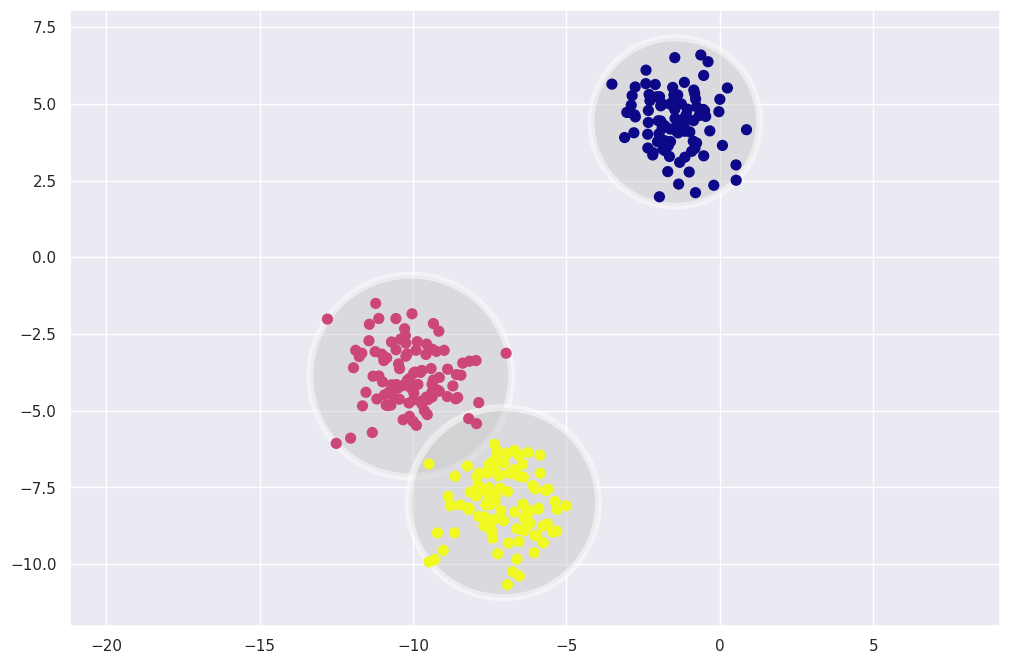

In [96]:
plt.figure(figsize=(12,8))
plot_kmeans(X,centroids,labels)
